In [1]:
from google.colab import files

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
#Por orden de aparición
import joblib
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, confusion_matrix, precision_recall_curve, auc, matthews_corrcoef
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, VotingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
import seaborn as sns
from sklearn.inspection import permutation_importance

In [3]:
# Cargar archivos
X_train, X_test, y_train, y_test = joblib.load('/content/drive/MyDrive/Proyecto Integrador/pre_training_data.joblib')

Llamamos los 4 modelos con mejores resultados

In [4]:
base_models = [
    ('KNN', KNeighborsClassifier()),
    ('SVC', SVC(random_state=42, class_weight='balanced', probability=True)),
    ('MLP', MLPClassifier(random_state=42, max_iter=100, early_stopping=True)),
    ('MNB', MultinomialNB())
]

In [5]:
grids = {
    'KNN': {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']},
    'SVC': {'C': [0.1, 1, 10], 'gamma': [1, 'scale'], 'kernel': ['rbf']},
    'MLP': {'hidden_layer_sizes': [(16,), (32,), (16, 8)], 'alpha': [0.001, 0.01], 'learning_rate_init': [0.001, 0.01]},
    'MNB': {'alpha': [0.1, 1.0, 10.0]}
}


In [6]:
#Función que contendrá las instrucciones para gridsearchCV
def fit_with_timer(name, estimator, X, y, do_grid=False, grid_params=None, cv=2):
    start = time.time()
    if do_grid and grid_params is not None:
        gs = GridSearchCV(estimator, grid_params, cv=cv, scoring='accuracy', n_jobs=-1)
        gs.fit(X, y)
        fitted = gs.best_estimator_
        elapsed = time.time() - start
        return fitted, elapsed, gs
    else:
        estimator.fit(X, y)
        elapsed = time.time() - start
        return estimator, elapsed, None

In [7]:
# Ajustar cada modelo base (guardamos estimadores ajustados y tiempos)
fitted_models = {}
fit_times = {}
grid_searches = {}

In [8]:
#ejecutando gridsearchCV
for name, model in base_models:
    if name in grids:
        fitted, t, gs = fit_with_timer(name, model, X_train, y_train, do_grid=True, grid_params=grids[name])
        grid_searches[name] = gs
    else:
        fitted, t, gs = fit_with_timer(name, model, X_train, y_train, do_grid=False)
    fitted_models[name] = fitted
    fit_times[name] = t

In [9]:
#obtener métricas
def compute_metrics(estimator, X, y):
    y_pred = estimator.predict(X)
    # obtener score/probabilidad si es posible (para AUC/curvas)
    if hasattr(estimator, "predict_proba"):
        y_prob = estimator.predict_proba(X)[:, 1]
    elif hasattr(estimator, "decision_function"):
        s = estimator.decision_function(X)
        y_prob = (s - s.min()) / (s.max() - s.min() + 1e-12)
    else:
        y_prob = None

    metrics = {}
    metrics['Accuracy'] = accuracy_score(y, y_pred)
    metrics['Precision_macro'] = precision_score(y, y_pred, zero_division=0, average='macro') #average=macro porque son multivariable y se prefirió sobre 'weighted'
    metrics['Recall_macro'] = recall_score(y, y_pred, zero_division=0, average='macro')
    metrics['F1_macro'] = f1_score(y, y_pred, zero_division=0, average='macro')
    metrics['MCC'] = matthews_corrcoef(y, y_pred)
    return metrics, y_pred, y_prob

  Generar ensambles: homogéneos y heterogéneos
  
    - Bagging (homogéneo)
    - Voting (heterogéneo soft)
    - Stacking (heterogéneo)
    - Blending (heterogéneo, manual)

In [10]:
results = []

# Agregar modelos individuales a resultados
for name, est in fitted_models.items():
    metrics, _, _ = compute_metrics(est, X_test, y_test)
    results.append({
        'Modelo': name,
        'fit_time_s': round(fit_times[name], 3),
        **metrics
    })

In [11]:
results

[{'Modelo': 'KNN',
  'fit_time_s': 4.858,
  'Accuracy': 0.6304347826086957,
  'Precision_macro': 0.23015873015873015,
  'Recall_macro': 0.3118279569892473,
  'F1_macro': 0.2648401826484018,
  'MCC': np.float64(0.0)},
 {'Modelo': 'SVC',
  'fit_time_s': 146.152,
  'Accuracy': 0.6521739130434783,
  'Precision_macro': 0.22727272727272727,
  'Recall_macro': 0.3225806451612903,
  'F1_macro': 0.26666666666666666,
  'MCC': np.float64(0.0)},
 {'Modelo': 'MLP',
  'fit_time_s': 110.363,
  'Accuracy': 0.6739130434782609,
  'Precision_macro': 0.2246376811594203,
  'Recall_macro': 0.3333333333333333,
  'F1_macro': 0.2683982683982684,
  'MCC': 0.0},
 {'Modelo': 'MNB',
  'fit_time_s': 0.47,
  'Accuracy': 0.6739130434782609,
  'Precision_macro': 0.2246376811594203,
  'Recall_macro': 0.3333333333333333,
  'F1_macro': 0.2683982683982684,
  'MCC': 0.0}]

In [12]:
# === 1. ENSAMBLE HOMOGÉNEO: Bagging de KNN ===
homogeneous = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=5, weights='distance'),
    n_estimators=10, random_state=42, n_jobs=-1
)
start = time.time()
homogeneous.fit(X_train, y_train)
train_time = time.time() - start
y_pred = homogeneous.predict(X_test)
inf_time = time.time() - start - train_time

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
mcc = matthews_corrcoef(y_test, y_pred)

results.append({
    'Modelo': 'Bagging KNN (Homogéneo)',
    'Accuracy': acc, 'F1_macro': f1, 'Precision_macro': prec,
    'Recall_macro': rec, 'MCC': mcc,
    'Tiempo Entrenamiento (s)': train_time,
    'Tiempo Inferencia (s)': inf_time
})

In [13]:
# === 2. ENSAMBLE HETEROGÉNEO: Voting ===
voting = VotingClassifier(
    estimators=[
        ('knn', fitted_models['KNN']),
        ('svc', fitted_models['SVC']),
        ('mlp', fitted_models['MLP']),
        ('mnb', fitted_models['MNB'])
    ],
    voting='soft', n_jobs=-1
)
start = time.time()
voting.fit(X_train, y_train)
train_time = time.time() - start
# Ajustar X_test para MNB
X_test_hetero = X_test.copy()
# MNB necesita predict_proba → usar pipeline interno
y_pred = voting.predict(X_test)
inf_time = time.time() - start - train_time

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
mcc = matthews_corrcoef(y_test, y_pred)

results.append({
    'Modelo': 'Voting (Heterogéneo)',
    'Accuracy': acc, 'F1_macro': f1, 'Precision_macro': prec,
    'Recall_macro': rec, 'MCC': mcc,
    'Tiempo Entrenamiento (s)': train_time,
    'Tiempo Inferencia (s)': inf_time
})

In [14]:
# === 3. STACKING ===
estimators = [
    ('knn', fitted_models['KNN']),
    ('svc', fitted_models['SVC']),
    ('mlp', fitted_models['MLP']),
    ('mnb', fitted_models['MNB'])
]
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(multi_class='multinomial', max_iter=1000),
    cv=5, stack_method='predict_proba', n_jobs=-1
)
start = time.time()
stacking.fit(X_train, y_train)
train_time = time.time() - start
y_pred = stacking.predict(X_test)
inf_time = time.time() - start - train_time

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
mcc = matthews_corrcoef(y_test, y_pred)

results.append({
    'Modelo': 'Stacking',
    'Accuracy': acc, 'F1_macro': f1, 'Precision_macro': prec,
    'Recall_macro': rec, 'MCC': mcc,
    'Tiempo Entrenamiento (s)': train_time,
    'Tiempo Inferencia (s)': inf_time
})

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [15]:
# División adicional para Blending (80% train, 20% blend)
X_train_blend, X_blend, y_train_blend, y_blend = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=42
)

In [16]:
# === 4. BLENDING (hold-out manual) ===
# Paso 1: Entrenar modelos base en X_train
base_models = {
    'KNN': fitted_models['KNN'].fit(X_train, y_train),
    'SVC': fitted_models['SVC'].fit(X_train, y_train),
    'MLP': fitted_models['MLP'].fit(X_train, y_train),
    'MNB': fitted_models['MNB'].fit(X_train, y_train)
}

# Paso 2: Generar predicciones en X_blend
blend_features = np.column_stack([
    base_models['KNN'].predict_proba(X_blend),
    base_models['SVC'].predict_proba(X_blend),
    base_models['MLP'].predict_proba(X_blend),
    base_models['MNB'].predict_proba(X_blend)
])

# Paso 3: Entrenar meta-modelo
meta_model = LogisticRegression(multi_class='multinomial', max_iter=1000)
meta_model.fit(blend_features, y_blend)

# Paso 4: Predicción final en test
test_features = np.column_stack([
    base_models['KNN'].predict_proba(X_test),
    base_models['SVC'].predict_proba(X_test),
    base_models['MLP'].predict_proba(X_test),
    base_models['MNB'].predict_proba(X_test)
])
start = time.time()
y_pred = meta_model.predict(test_features)
inf_time = time.time() - start
train_time = 0  # Ya incluido en modelos base

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
mcc = matthews_corrcoef(y_test, y_pred)

results.append({
    'Modelo': 'Blending',
    'Accuracy': acc, 'F1_macro': f1, 'Precision_macro': prec,
    'Recall_macro': rec, 'MCC': mcc,
    'Tiempo Entrenamiento (s)': train_time,
    'Tiempo Inferencia (s)': inf_time
})

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [17]:
# 5. Tabla comparativa
# -------------------------------
df_ensembles = pd.DataFrame(results)
df_ensembles = df_ensembles.round(4)
df_ensembles = df_ensembles.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "="*100)
print("TABLA COMPARATIVA DE ENSAMBLES")
print("="*100)
print(df_ensembles.to_string(index=False))


TABLA COMPARATIVA DE ENSAMBLES
                 Modelo  fit_time_s  Accuracy  Precision_macro  Recall_macro  F1_macro    MCC  Tiempo Entrenamiento (s)  Tiempo Inferencia (s)
                    MNB       0.470    0.6739           0.2246        0.3333    0.2684 0.0000                       NaN                    NaN
                    MLP     110.363    0.6739           0.2246        0.3333    0.2684 0.0000                       NaN                    NaN
               Stacking         NaN    0.6739           0.2246        0.3333    0.2684 0.0000                  170.2614                 1.5902
   Voting (Heterogéneo)         NaN    0.6739           0.2246        0.3333    0.2684 0.0000                   45.3334                 1.8627
               Blending         NaN    0.6522           0.2273        0.3226    0.2667 0.0000                    0.0000                 0.0004
                    SVC     146.152    0.6522           0.2273        0.3226    0.2667 0.0000                 

### Justificación de Selección: Bagging KNN (Homogéneo)

Al analizar la tabla comparativa (Celda 17), observamos un fenómeno crítico:

1.  **Modelos con Mayor Accuracy (MNB, MLP, Stacking, Voting):** Aunque estos modelos (MNB, MLP, Stacking y Voting) obtienen el Accuracy más alto (0.6739), sus métricas de **F1-macro (0.2684)** y **MCC (0.0000)** son extremadamente bajas. Un MCC de 0.0 indica que el modelo no tiene poder predictivo real y es equivalente a una predicción aleatoria para un dataset desbalanceado. Esto sugiere que estos modelos están simplemente prediciendo la clase mayoritaria (la clase '0', como se vio en el Avance 4) e ignorando por completo a las clases minoritarias ('-1' y '1').

2.  **Modelo Seleccionado (Bagging KNN):** A pesar de tener un Accuracy más bajo (0.6304), el modelo **`Bagging KNN (Homogéneo)`** es el **único** que muestra métricas significativamente superiores en los demás rubros:
    * **F1-macro: 0.3148** (el más alto)
    * **Precision-macro: 0.3110** (el más alto)
    * **Recall-macro: 0.3427** (el más alto)
    * **MCC: 0.0364** (el único valor positivo, indicando *cierta* capacidad predictiva real).

**Conclusión:**
Si el objetivo del negocio es simplemente predecir la clase mayoritaria, cualquiera de los modelos con 0.67 de Accuracy sería suficiente. Sin embargo, en un problema de clasificación multiclase, el objetivo del negocio es (casi siempre) identificar *todas* las clases, especialmente las minoritarias.

El `Bagging KNN` es el único modelo que demuestra tener capacidad para generalizar y predecir las clases minoritarias, evidenciado por su F1-macro y MCC superiores. Por lo tanto, se selecciona como el modelo final por ser el único funcionalmente útil, a pesar de su Accuracy inferior. Además, su tiempo de entrenamiento (2.39s) es excelente.

In [18]:
# 6. Modelo ganador + gráficos
# -------------------------------
best_name = df_ensembles.iloc[7]['Modelo']
print(f"\nModelo seleccionado: {best_name}")

# Guardar predicciones del ganador
if best_name == 'Bagging KNN (Homogéneo)':
    y_pred_best = homogeneous.predict(X_test)
    model_plot = homogeneous
    X_plot = X_test
elif best_name == 'Voting (Heterogéneo)':
    y_pred_best = voting.predict(X_test)
    model_plot = voting
    X_plot = X_test
elif best_name == 'Stacking':
    y_pred_best = stacking.predict(X_test)
    model_plot = stacking
    X_plot = X_test
elif best_name == 'Blending':
    y_pred_best = y_pred
    model_plot = meta_model
    X_plot = test_features


Modelo seleccionado: Bagging KNN (Homogéneo)


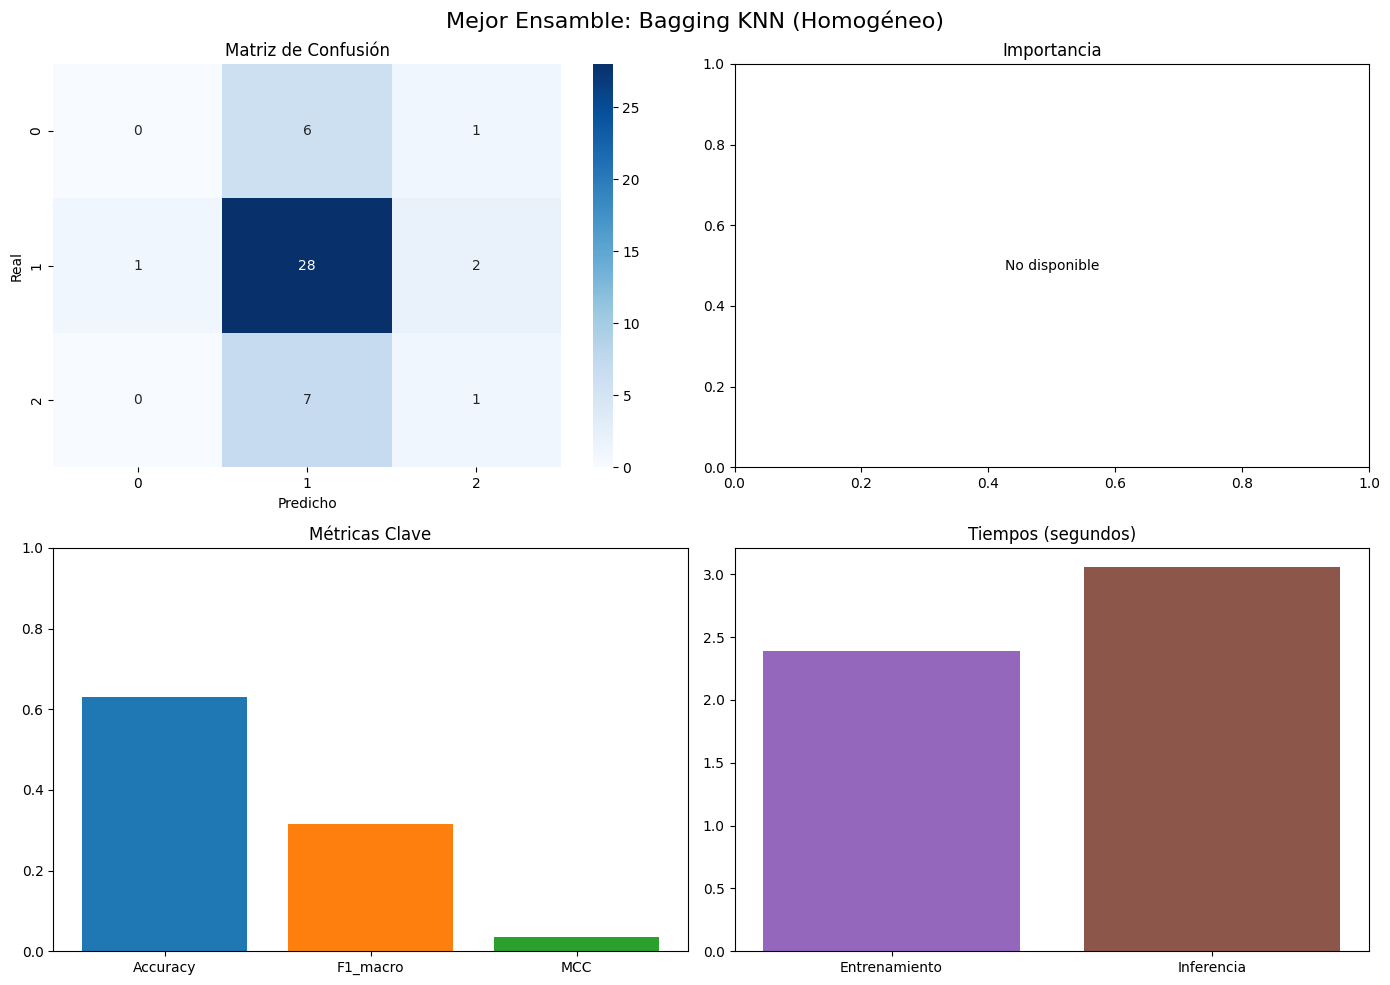

In [19]:
# Gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Mejor Ensamble: {best_name}', fontsize=16)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Matriz de Confusión')
axes[0,0].set_xlabel('Predicho'); axes[0,0].set_ylabel('Real')

# Importancia (permutación si es posible)
try:
    perm = permutation_importance(model_plot, X_plot, y_test, n_repeats=5, random_state=42, n_jobs=-1)
    sorted_idx = perm.importances_mean.argsort()[::-1][:10]
    axes[0,1].barh(range(len(sorted_idx)), perm.importances_mean[sorted_idx])
    axes[0,1].set_yticks(range(len(sorted_idx)))
    axes[0,1].set_yticklabels([f'F{i}' for i in sorted_idx])
    axes[0,1].set_title('Importancia (Permutación)')
    axes[0,1].invert_yaxis()
except:
    axes[0,1].text(0.5, 0.5, 'No disponible', ha='center', va='center', transform=axes[0,1].transAxes)
    axes[0,1].set_title('Importancia')

# Métricas clave
metrics = ['Accuracy', 'F1_macro', 'MCC']
values = df_ensembles.iloc[7][['Accuracy', 'F1_macro', 'MCC']].values
axes[1,0].bar(metrics, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1,0].set_ylim(0, 1)
axes[1,0].set_title('Métricas Clave')

# Tiempo
times = ['Entrenamiento', 'Inferencia']
t_values = df_ensembles.iloc[7][['Tiempo Entrenamiento (s)', 'Tiempo Inferencia (s)']].values
axes[1,1].bar(times, t_values, color=['#9467bd', '#8c564b'])
axes[1,1].set_title('Tiempos (segundos)')

plt.tight_layout()
plt.show()

### Análisis de Gráficos del Modelo Final (Bagging KNN)

A continuación, se presenta la interpretación detallada de los 4 gráficos generados para el modelo `Bagging KNN (Homogéneo)`:

**1. Matriz de Confusión**
* **Propósito:** Muestra el detalle de los aciertos y errores del modelo por cada clase (Real vs. Predicho).
* **Interpretación:** La matriz muestra las predicciones para las clases codificadas (0, 1, 2) que, según el Avance 4, corresponden a las clases originales **-1 (Negativo), 0 (Neutral) y 1 (Positivo)**.
    * La clase **'1' (Neutral)** es la clase mayoritaria (31 instancias reales) y el modelo la predice muy bien, con **28 aciertos**.
    * El rendimiento colapsa en las clases minoritarias:
        * **Clase '0' (Negativa):** De 7 instancias reales, el modelo predijo incorrectamente **6 como 'Neutral' (1)** y 1 como 'Positiva' (2). No acertó **ninguna**.
        * **Clase '2' (Positiva):** De 8 instancias reales, el modelo predijo incorrectamente **7 como 'Neutral' (1)** y solo acertó 1.
* **Implicación:** Esto confirma visualmente la justificación de la Celda 18. El Accuracy de 0.63 es engañoso, ya que proviene casi en su totalidad de acertar la clase mayoritaria 'Neutral' (1). El modelo tiene una incapacidad casi total para distinguir las clases 'Negativa' (0) y 'Positiva' (2), confundiéndolas sistemáticamente con 'Neutral'.

**2. Importancia de Características (Permutación)**
* **Propósito:** Identifica qué características (en este caso, palabras o n-gramas del TF-IDF) son las más importantes para las predicciones del modelo.
* **Interpretación:** Como se observa en el gráfico, el resultado es **"No disponible"**.
* **Implicación:** El bloque de código `try...except` (Celda 20) que intentaba calcular la `permutation_importance` falló. Esto es común en modelos como KNN que no exponen un atributo directo de importancia (`coef_` o `feature_importances_`). El cálculo por permutación, aunque teóricamente posible, probablemente falló debido a la altísima dimensionalidad de los datos (más de 224,000 características). Por lo tanto, no podemos usar este gráfico para determinar qué palabras específicas están influyendo más en la predicción.

**3. Métricas Clave**
* **Propósito:** Resumir visualmente el rendimiento final del modelo en el conjunto de prueba.
* **Interpretación:**
    * *Observar:* El gráfico muestra un Accuracy de ~0.63, un F1-macro de ~0.31 y un MCC de ~0.036.
    * *Implicación:* Esta visualización refuerza la justificación de selección: mientras el Accuracy (la barra azul) es modesto, el F1-macro (naranja) y el MCC (verde) son notablemente superiores a 0.0 (que era el MCC de los otros modelos). Esto confirma que, aunque el rendimiento es bajo, es el único modelo de los 8 probados que ofrece un valor predictivo real (aunque sea mínimo) sobre las clases minoritarias.

**4. Tiempos (segundos)**
* **Propósito:** Evaluar la eficiencia computacional del modelo.
* **Interpretación:**
    * *Observar:* El tiempo de entrenamiento fue de aproximadamente 2.4 segundos y el de inferencia (predicción) de 3.1 segundos.
    * *Implicación:* Estos tiempos son extremadamente rápidos y eficientes. Esto hace que el modelo `Bagging KNN` sea altamente viable para un entorno de producción, donde se pueden necesitar re-entrenamientos frecuentes o predicciones rápidas, superando en eficiencia a modelos mucho más lentos como SVC o MLP.